# DisasterM3 — D4 Champion Model + Pre-D4 Ablations
**Task D4 (Champion Model Integration).** One config-driven notebook that runs every pre-D4
ablation (R1–R6), the evaluation-only re-scoring of old checkpoints (E0), and the final
champion (R7). Built from `segmentation-model (1).ipynb` (the B1 baseline) with code reused
from Aryan (A3 copy-paste), Noman (Phased Loss) and Ridita (RandomCrop, TTA).

### Why a new protocol (read before quoting any number)
The original ablation results are **not comparable with each other**: the B/C runs evaluate a
*resized* 512 image, the D runs evaluate a *random* 768 crop (different every call), the
checkpoint is chosen with a per-image metric that differs from the reported one, and the A3
CSV came from a run whose copy-paste bank leaked validation buildings. See
`../Ablation_Study_Reference_and_QA_Prep.md` → *Errata*.

**E-protocol (used for every number this notebook reports):**
- Same 645 validation images (`train_test_split(pairs, test_size=0.1, random_state=42)`).
- **Full native image + native mask** — no resize, no crop. Batch 1, padded to a multiple of 32.
- Dataset-level confusion matrix → per-class IoU / Precision / Recall / F1 / F2, plus macro means.
- **Reported checkpoint = last epoch** (cosine LR ends near 0). The val set is *not* used to pick
  the checkpoint; best-by-val is logged for reference only.

### Run table — set `EXPERIMENT` in Cell 2
| ID | Change vs R1 | Question it answers |
|---|---|---|
| **E0** | eval-only: re-score old checkpoints | What do B1 / C5 / D1c really score under one protocol? |
| **R1** | — (U-Net, ResNet-50, Phased FT(0.3/0.7/2.0)→+Lovász, RandomCrop 768, bs 8, 40 ep, seed 42) | New reference: C5 recipe at native resolution |
| **R2** | + copy-paste (train-only bank, pasted at native scale) | Does copy-paste help once the leak and 2× scale bug are fixed? |
| **R3** | FT params 0.25/0.75/1.33 (Noman's C3) | Do C3's params beat C2's inside the phased loss? |
| **R4** | U-Net++ decoder (bs 4 × accum 2) | Does U-Net++ win once the loss is fixed? |
| **R5** | + WeightedRandomSampler (10× / 5× / 1×) | Does Aryan's sampler help on the champion recipe? |
| **R6** | seed 7 | **Noise bar**: how much does mIoU move from the seed alone? |
| **R8** | + guide's enhanced augmentation (HSV, CLAHE, Elastic, GridDistortion, CoarseDropout) | Tier-2 item #7 of the improvement guide — planned, never run by anyone |
| **R7** | R1 + every R2–R5/R8 change that beat R1 by more than \|R1 − R6\| | The champion |

**Decision rule for R7:** a component is kept only if its run beats R1 on **mIoU** by more than
the seed noise \|R1 − R6\| *and* does not lower **Destroyed IoU**. Fill `PRESETS["R7"]` with
the kept flags. If R7 scores below the best single run, report the best single run as champion.

**Phase Gate (team_task_assignments.md, Day 10):** Cell 10 prints whether the run passes
*mIoU > 0.52 **and** Destroyed IoU > 0.30*. If the champion fails, the plan triggers Phase 2
(external data, Task D5). The improvement guide (Tier 5) also says the two-stage pipeline is the
lever to pull when Destroyed IoU stays below 0.30. For reference, C5's Destroyed IoU is 0.279.

### Deliberate deviations from the D4 spec in `team_task_assignments.md`
- **The spec stacks every member's "best" component.** Here a component goes into R7 only if
  its own run beats R1 by more than seed noise, because the old results were single-seed and
  were scored in different ways.
- **No sliding window.** The spec asks for TTA + sliding window. A U-Net is fully convolutional,
  so the whole 1024×1024 image goes through in one pass (padded to a multiple of 32). A sliding
  window only exists to fit a crop-sized input, so here it would only add stitching seams.
- **Best architecture = U-Net**, per Tamanna's results. R4 re-tests U-Net++ under the better loss.
- **lr 1e-4 / weight decay 1e-5, not the 5e-4 in the audit doc's champion recipe.** 5e-4 is
  the baseline's *unused* `LEARNING_RATE` config value. B1, every C run and every D run actually
  trained with 1e-4 / 1e-5 (hard-coded in `AdamW(...)`). Only B2–B5 used 5e-4 / 1e-4, which is
  one reason they aren't comparable with B1.
- **The reported checkpoint is the last epoch, not best-by-val.** The spec's snippet saves the
  best-by-val model and then reports on that same val set, which is optimistically biased.

R2–R6 are independent — run them in parallel on different members' Kaggle accounts. Run R1 and
R6 first so the noise bar is known early.

### How to run ("Run All" workflow)
1. GPU T4, internet ON, DisasterM3 mirror dataset attached, `HF_TOKEN` secret (write-scoped).
2. **First time:** set `SMOKE_TEST = True` in Cell 2 and Run All (≈ 5 min) to catch errors cheaply.
3. Set `SMOKE_TEST = False`, pick `EXPERIMENT`, Run All. Cell 1 may install deps and halt →
   restart kernel → Run All again.
4. A ResNet-50 run at 768 takes ≈ 9–11 h. The time guard saves `last.pth` and pushes it to the
   per-experiment HF repo before the 12 h cap. **Next session: Run All again with the same
   `EXPERIMENT`** — Cell 8 resumes automatically from HF.
5. When training reaches the final epoch, Cell 10 writes `D4_<EXPERIMENT>.csv` (standard + TTA rows).

In [1]:
# ── Cell 1: Environment Setup (Run-All safe) ──────────────────────────────
# Kaggle's image moved to Python 3.13, which has no torch 2.4.1 wheel. Use Kaggle's own
# torch/torchvision/opencv and pin only the libraries whose API this notebook depends on.
import importlib.metadata as _md
import os, sys, subprocess

PINS = {
    "segmentation-models-pytorch": "0.3.4",   # baseline version (checkpoint key layout)
    "albumentations": "1.4.21",               # 1.x API (PadIfNeeded value=/mask_value=)
}

def _mismatched():
    out = []
    for pkg, want in PINS.items():
        try:
            have = _md.version(pkg)
        except _md.PackageNotFoundError:
            have = "not installed"
        if have != want:
            out.append(f"{pkg}: {have} → {want}")
    return out

if _mismatched():
    print("⏳ Installing pinned versions:")
    for _m in _mismatched():
        print(f"   {_m}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    *(f"{k}=={v}" for k, v in PINS.items()), "huggingface_hub[hf_xet]"],
                   check=True)                # pip failure stops the run here
    if _mismatched():
        raise RuntimeError(f"Pins still wrong after install: {_mismatched()}")
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") == "Batch":
        # background "Save & Run All": nothing imported yet, so new versions load on first import
        print("✓ Dependencies installed (background run) — continuing without restart.")
    else:
        raise SystemExit("✓ Dependencies installed. RESTART THE KERNEL NOW "
                         "(Run → Restart & clear cell outputs), then Run All again.")
else:
    print("✓ All pinned versions already installed — proceeding.")

import torch
print(f"  torch {torch.__version__}, python {sys.version.split()[0]}")


⏳ Installing pinned versions:
   segmentation-models-pytorch: not installed → 0.3.4
   albumentations: 2.0.8 → 1.4.21
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.9/227.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 63.9 MB/s eta 0:00:00
✓ Dependencies installed (background run) — continuing without restart.
  torch 2.11.0+cu128, python 3.13.15


In [2]:
# ── Cell 2: Configuration — pick EXPERIMENT, everything else follows ─────
import os
import json
import time
import random
import torch
from pathlib import Path

# ── Paths (same DisasterM3 mirror dataset mount as the baseline notebook) ──
DATA_ROOT = Path("/kaggle/input/datasets/abrarmohammedtanzim/disasterm3-mirror/DisasterM3_Instruct")
MANIFEST_PATH = DATA_ROOT / "train_release.json"
WORK_DIR = Path("/kaggle/working")

NUM_CLASSES = 4               # 0=Background, 1=Intact, 2=Damaged, 3=Destroyed
CLASS_NAMES = ["Background", "Intact", "Damaged", "Destroyed"]

EXPERIMENT = "R4"             # E0 | R1 | R2 | R3 | R4 | R5 | R6 | R8 | R7
SMOKE_TEST = False            # True = tiny 1-epoch run to check the notebook end-to-end

# ── R1 reference recipe (Noman's C5 champion + Ridita's 768 native crop) ──
BASE = dict(
    arch="Unet", encoder="resnet50",
    crop=768, batch=8, accum=1,                      # effective batch = batch * accum
    ft_alpha=0.3, ft_beta=0.7, ft_gamma=2.0,         # Focal Tversky (C2/C4/C5 params)
    lovasz_start_frac=0.8, lovasz_weight=0.4,        # epochs 32-40: 0.6*FT + 0.4*Lovasz
    use_copy_paste=False, paste_prob=0.5, max_paste=3,
    use_sampler=False, sampler_weights=(1.0, 1.0, 5.0, 10.0),  # per image: max class present
    use_enhanced_aug=False,                          # guide §3B extra color/spatial/dropout augs
    seed=42, epochs=40, lr=1e-4, weight_decay=1e-5,
    eval_only=False,
)

# ── One variable per run, always relative to R1 ──
PRESETS = {
    "R1": {},
    "R2": dict(use_copy_paste=True),
    "R3": dict(ft_alpha=0.25, ft_beta=0.75, ft_gamma=1.33),
    # Note: accumulation keeps the effective batch at 8, but BatchNorm still only sees 4 images.
    # Don't combine this with the sampler in R7 unless batch >= 8 fits (guide §3D caveat).
    "R4": dict(arch="UnetPlusPlus", batch=4, accum=2),   # if OOM: batch=2, accum=4
    "R5": dict(use_sampler=True),
    "R6": dict(seed=7),
    "R8": dict(use_enhanced_aug=True),
    # R7: fill in ONLY the R2-R5 changes that beat R1 by more than |R1 - R6| (see Cell 0)
    "R7": dict(),
    "E0": dict(eval_only=True),
}
CFG = {**BASE, **PRESETS[EXPERIMENT]}

# ── E0: old checkpoints to re-score under the E-protocol ──
# input_mode="resize512" for models trained with A.Resize(512) (B*, C*), "native" for crop-trained (D1b/D1c).
# Either set hf_repo+filename, or local_path (e.g. a Kaggle dataset you uploaded the .pth to).
# ⚠ Every old notebook pushed to the SAME repo below, so its best_model.pth is whichever run
#   pushed last — confirm which model it is before trusting the label.
# B2–B5: Tamanna's best_model_*.pth are in Essential_task_delegation/Tamanna_task/ — upload that
# folder as a Kaggle dataset and fix TAMANNA_CKPTS. (Their keys were checked: ResNet-34 encoders.)
TAMANNA_CKPTS = "/kaggle/input/<your-dataset>"
EVAL_CHECKPOINTS = [
    dict(name="B1_baseline_unet_r34", arch="Unet", encoder="resnet34", input_mode="resize512",
         hf_repo="AbrarAlam/disasterm3-unet-checkpoints-2", filename="best_model.pth", local_path=None),
    dict(name="B2_UnetPlusPlus", arch="UnetPlusPlus", encoder="resnet34", input_mode="resize512",
         local_path=f"{TAMANNA_CKPTS}/best_model_B2_UnetPlusPlus.pth"),
    dict(name="B3_UnetPlusPlus_scse", arch="UnetPlusPlus", encoder="resnet34", input_mode="resize512",
         local_path=f"{TAMANNA_CKPTS}/best_model_B3_UnetPlusPlus_scse.pth",
         model_kwargs=dict(decoder_attention_type="scse")),
    dict(name="B4_DeepLabV3Plus", arch="DeepLabV3Plus", encoder="resnet34", input_mode="resize512",
         local_path=f"{TAMANNA_CKPTS}/best_model_B4_DeepLabV3Plus.pth"),
    dict(name="B5_MAnet", arch="MAnet", encoder="resnet34", input_mode="resize512",
         local_path=f"{TAMANNA_CKPTS}/best_model_B5_MAnet.pth"),
    # dict(name="C5_resnet50_phased", arch="Unet", encoder="resnet50", input_mode="resize512",
    #      local_path="/kaggle/input/<dataset>/best_model.pth"),
    # dict(name="D1c_crop768", arch="Unet", encoder="resnet34", input_mode="native",
    #      local_path="/kaggle/input/<dataset>/best_model.pth"),
]

if SMOKE_TEST:
    CFG.update(epochs=1, crop=256, batch=2, accum=1)

# ── Runtime ──
NUM_WORKERS = 2
VAL_EVERY_N_EPOCHS = 2        # full-image val is ~1 min; the last epoch is always validated
TIME_LIMIT_HOURS = 11.3       # stop + push before Kaggle's 12 h cap
HF_REPO_ID = f"AbrarAlam/disasterm3-d4-{EXPERIMENT}"   # one repo per experiment (no overwrites)
RUN_DIR = WORK_DIR / f"d4_{EXPERIMENT}"
RUN_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✓ Experiment {EXPERIMENT}{'  [SMOKE TEST]' if SMOKE_TEST else ''}")
for k, v in CFG.items():
    print(f"  {k:<18} {v}")
print(f"  Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

✓ Experiment R4
  arch               UnetPlusPlus
  encoder            resnet50
  crop               768
  batch              4
  accum              2
  ft_alpha           0.3
  ft_beta            0.7
  ft_gamma           2.0
  lovasz_start_frac  0.8
  lovasz_weight      0.4
  use_copy_paste     False
  paste_prob         0.5
  max_paste          3
  use_sampler        False
  sampler_weights    (1.0, 1.0, 5.0, 10.0)
  use_enhanced_aug   False
  seed               42
  epochs             40
  lr                 0.0001
  weight_decay       1e-05
  eval_only          False
  Device: Tesla T4


In [3]:
# ── Cell 3: Seeding ─────────────────────────────────────────────────────────
# Seeds data order, augmentation and weight init. cuDNN stays non-deterministic for speed —
# that residual randomness is exactly what R6 (seed 7) measures as the noise bar.
import numpy as np

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

def worker_init_fn(worker_id):
    s = torch.initial_seed() % 2**32
    random.seed(s)
    np.random.seed(s)

seed_everything(CFG["seed"])
data_generator = torch.Generator().manual_seed(CFG["seed"])
print(f"✓ Seeded with {CFG['seed']}")

✓ Seeded with 42


## 1. Load & Prepare Segmentation Data
Cell 4 is copied verbatim from the baseline notebook so every run sees the same 6,443 pairs.

In [4]:
# ── Cell 4: Load manifest and extract segmentation entries ────────────────
# Mirrors train_qwen_disasterm3.ipynb Cell 4: same manifest, same path
# resolution logic, but this time we KEEP the segmentation entries and
# DROP the text-QA entries (exact inverse of the VLM notebook).
# ── Cell 4 (rewritten): Build combined multi-class masks from 3 binary sources ──
import cv2
import numpy as np
import os
from collections import Counter, defaultdict
from pathlib import Path
import json

with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)
print(f"Loaded {len(raw_data):,} entries from manifest")

# ── Filter: ONLY Building Damage Assessment segmentation entries ──
bda_entries = [
    e for e in raw_data
    if e.get("task") == "Referring Expression Segmentation"
    and e.get("cls_description") == "Building Damage Assessment"
]
print(f"Building Damage Assessment entries: {len(bda_entries):,}")

# ── Path resolution (same logic as before) ──
def resolve_path(rel_path):
    if not rel_path:
        return None
    rel_path = rel_path.replace("\\", "/")
    filename = Path(rel_path).name
    candidates = [
        DATA_ROOT / rel_path,
        DATA_ROOT / "train_images" / rel_path,
        DATA_ROOT / "train_images" / "train_images" / filename,
        DATA_ROOT / "masks" / rel_path,
        DATA_ROOT / "masks" / "masks" / filename,
    ]
    for c in candidates:
        if c.exists():
            return str(c)
    return None

# ── Group entries by underlying post-disaster image ──
by_image = defaultdict(dict)  # post_image_path -> {folder_type: mask_path}

for e in bda_entries:
    post_img = e.get("post_image_path", "")
    if e.get("image_type") != "Optical":   # skip SAR duplicates, keep optical only
        continue
    mask_rel = e.get("ground_truth", "")
    folder = Path(mask_rel.replace("\\", "/")).parent.name  # e.g. train_building_intact_mask
    resolved = resolve_path(mask_rel)
    if resolved:
        by_image[post_img][folder] = resolved
        by_image[post_img]["post_image_path"] = post_img

print(f"Unique images with at least one mask: {len(by_image):,}")

# ── Build combined (image, mask) pairs ──
FOLDER_TO_CLASS = {
    "train_building_intact_mask": 1,
    "train_building_damaged_mask": 2,
    "train_building_destroyed_mask": 3,   # use 2 here instead if you want to collapse into "damaged"
}

# ── FIX: Create temporary directory on Kaggle hard drive for masks ──
os.makedirs("/tmp/combined_masks", exist_ok=True)

pairs = []
skipped_img = 0

for post_img, mask_dict in by_image.items():
    img_path = resolve_path(post_img)
    if not img_path:
        skipped_img += 1
        continue

    combined_mask = None
    for folder, class_id in FOLDER_TO_CLASS.items():
        mask_path = mask_dict.get(folder)
        if mask_path is None:
            continue
        m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if m is None:
            continue
        if combined_mask is None:
            combined_mask = np.zeros_like(m, dtype=np.uint8)
        combined_mask[m > 0] = class_id   # later classes overwrite earlier if they overlap

    if combined_mask is None:
        continue  # no valid masks found for this image at all

    # ── FIX: Save mask to hard drive instead of RAM ──
    mask_filename = Path(img_path).name
    save_path = f"/tmp/combined_masks/{mask_filename}"
    cv2.imwrite(save_path, combined_mask)

    pairs.append({
        "image_path": img_path,
        "mask_path": save_path,   # Store the string path, NOT the array!
    })

print(f"\n✓ Built {len(pairs):,} valid (image, mask) pairs")
print(f"  Skipped (image not found): {skipped_img:,}")

# Sanity check
if pairs:
    print(f"\n  Sample: {pairs[0]['image_path']}")
    print(f"  Mask saved at: {pairs[0]['mask_path']}")

Loaded 92,968 entries from manifest
Building Damage Assessment entries: 14,531
Unique images with at least one mask: 6,443

✓ Built 6,443 valid (image, mask) pairs
  Skipped (image not found): 0

  Sample: /kaggle/input/datasets/abrarmohammedtanzim/disasterm3-mirror/DisasterM3_Instruct/train_images/train_images/bata_explosion_post_0.png
  Mask saved at: /tmp/combined_masks/bata_explosion_post_0.png


In [5]:
# ── Cell 5: Datasets — native-resolution crops for train, FULL image for val ──
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class DisasterM3SegDataset(Dataset):
    """Post-disaster image + pre-merged mask (0=BG, 1=Intact, 2=Damaged, 3=Destroyed)."""

    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        image = cv2.imread(pair["image_path"])
        mask = cv2.imread(pair["mask_path"], cv2.IMREAD_GRAYSCALE)
        if image is None or mask is None:
            return self.__getitem__((idx + 1) % len(self))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if mask.shape != image.shape[:2]:   # guard: crops need identical shapes
            mask = cv2.resize(mask, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented["image"], augmented["mask"]
        return image, mask.long()

NORMALIZE = A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

# R8 only: the "Recommended Enhanced Pipeline" from segmentation_improvement_guide.md §3B
ENHANCED_AUGS = [
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.2),
    A.ElasticTransform(alpha=30, sigma=5, p=0.15),
    A.GridDistortion(p=0.15),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, fill_value=0, p=0.2),
] if CFG["use_enhanced_aug"] else []

train_transform = A.Compose([
    A.PadIfNeeded(CFG["crop"], CFG["crop"], border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0),
    A.RandomCrop(CFG["crop"], CFG["crop"]),          # native resolution — no downscaling
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    *ENHANCED_AUGS,
    NORMALIZE,
    ToTensorV2(),
])

# E-protocol: the whole native image, deterministic (no RandomCrop, no Resize)
val_transform = A.Compose([NORMALIZE, ToTensorV2()])

# Same split as every previous experiment
train_pairs, val_pairs = train_test_split(pairs, test_size=0.1, random_state=42)
if SMOKE_TEST:
    train_pairs, val_pairs = train_pairs[:16], val_pairs[:8]

train_dataset = DisasterM3SegDataset(train_pairs, transform=train_transform)
val_dataset = DisasterM3SegDataset(val_pairs, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"✓ Train: {len(train_dataset):,} images (random {CFG['crop']}×{CFG['crop']} native crops)")
print(f"✓ Val:   {len(val_dataset):,} images (full native resolution, batch 1)")

/usr/local/lib/python3.13/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


✓ Train: 5,798 images (random 768×768 native crops)
✓ Val:   645 images (full native resolution, batch 1)


## 2. Optional data components (R2 copy-paste, R5 sampler)
**Copy-paste** reuses Aryan's A3 code with two fixes: the instance bank comes from
`train_pairs` only (no val leakage), and pasting happens *after* the native crop, so pasted
buildings keep their real size (in A3 they were pasted onto 512-resized images → 2× too big).

In [6]:
# ── Cell 6: Copy-Paste (R2) and WeightedRandomSampler (R5) ─────────────────
import glob
from torch.utils.data import WeightedRandomSampler
from tqdm.auto import tqdm

class CopyPasteAugDataset(Dataset):
    """Wraps the base dataset. Randomly pastes minority-class instances onto the (cropped,
    normalized) image tensor. From Aryan_Task/A3_augmentation_copypaste.ipynb."""

    def __init__(self, base_dataset, instance_dir, paste_prob=0.5, max_paste=3):
        self.base = base_dataset
        self.paste_prob = paste_prob
        self.max_paste = max_paste
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

        self.instances = []
        for cls_id, cls_name in [(2, "damaged"), (3, "destroyed")]:
            for img_path in sorted(glob.glob(f"{instance_dir}/{cls_name}/img_*.png")):
                inst_img = cv2.imread(img_path)
                inst_mask = cv2.imread(img_path.replace("img_", "mask_"), cv2.IMREAD_GRAYSCALE)
                if inst_img is not None and inst_mask is not None:
                    self.instances.append((inst_img, (inst_mask > 127).astype(np.uint8), cls_id))
        print(f"Loaded {len(self.instances)} minority instances for Copy-Paste")

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, mask = self.base[idx]
        if random.random() < self.paste_prob and self.instances:
            img_np = image.permute(1, 2, 0).numpy().copy()   # [H, W, C], normalized
            mask_np = mask.numpy().copy()
            for _ in range(random.randint(1, self.max_paste)):
                inst_img, inst_mask, cls_id = random.choice(self.instances)
                ih, iw = inst_mask.shape[:2]
                if ih >= img_np.shape[0] or iw >= img_np.shape[1]:
                    continue
                y = random.randint(0, img_np.shape[0] - ih)
                x = random.randint(0, img_np.shape[1] - iw)
                paste = inst_mask > 0
                # BGR (cv2) -> RGB, then the same normalization as the base dataset
                inst_norm = (inst_img[..., ::-1].astype(np.float32) / 255.0 - self.mean) / self.std
                img_np[y:y+ih, x:x+iw][paste] = inst_norm[paste]
                mask_np[y:y+ih, x:x+iw][paste] = cls_id
            image = torch.from_numpy(img_np).permute(2, 0, 1).float()
            mask = torch.from_numpy(mask_np).long()
        return image, mask


def extract_instances(train_pairs, instance_dir, min_area=100):
    """A3 Step 1 — train_pairs ONLY. Cached: skipped if the bank already exists."""
    done_flag = Path(instance_dir) / "DONE.json"
    if done_flag.exists():
        return json.loads(done_flag.read_text())
    for name in ("damaged", "destroyed"):
        os.makedirs(f"{instance_dir}/{name}", exist_ok=True)
    count = {"damaged": 0, "destroyed": 0}
    for pair in tqdm(train_pairs, desc="Extract instances"):
        img = cv2.imread(pair["image_path"])
        mask = cv2.imread(pair["mask_path"], cv2.IMREAD_GRAYSCALE)
        if img is None or mask is None:
            continue
        if mask.shape != img.shape[:2]:
            mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        for cls_id, name in [(2, "damaged"), (3, "destroyed")]:
            binary = (mask == cls_id).astype(np.uint8)
            if binary.sum() == 0:
                continue
            n, labels, stats, _ = cv2.connectedComponentsWithStats(binary)
            for lid in range(1, n):
                if stats[lid, cv2.CC_STAT_AREA] < min_area:
                    continue
                x, y = stats[lid, cv2.CC_STAT_LEFT], stats[lid, cv2.CC_STAT_TOP]
                w, h = stats[lid, cv2.CC_STAT_WIDTH], stats[lid, cv2.CC_STAT_HEIGHT]
                cv2.imwrite(f"{instance_dir}/{name}/img_{count[name]}.png", img[y:y+h, x:x+w])
                cv2.imwrite(f"{instance_dir}/{name}/mask_{count[name]}.png",
                            (labels[y:y+h, x:x+w] == lid).astype(np.uint8) * 255)
                count[name] += 1
    done_flag.write_text(json.dumps(count))
    return count


def image_sample_weights(pairs, class_weights):
    """R5: each image gets the weight of the rarest class it contains (Aryan's A2 scheme)."""
    weights = []
    for pair in tqdm(pairs, desc="Sampler weights"):
        mask = cv2.imread(pair["mask_path"], cv2.IMREAD_GRAYSCALE)
        present = np.unique(mask) if mask is not None else [0]
        weights.append(max(class_weights[int(c)] for c in present if int(c) < NUM_CLASSES))
    return torch.tensor(weights, dtype=torch.double)


if not CFG["eval_only"]:
    train_ds = train_dataset
    if CFG["use_copy_paste"]:
        inst_dir = str(WORK_DIR / ("minority_instances_smoke" if SMOKE_TEST else "minority_instances"))
        counts = extract_instances(train_pairs, inst_dir)
        print(f"✓ Instance bank (train only): {counts}")
        train_ds = CopyPasteAugDataset(train_dataset, inst_dir, CFG["paste_prob"], CFG["max_paste"])

    if CFG["use_sampler"]:
        w = image_sample_weights(train_pairs, CFG["sampler_weights"])
        sampler = WeightedRandomSampler(w, num_samples=len(w), replacement=True, generator=data_generator)
        print(f"✓ WeightedRandomSampler: {int((w == max(CFG['sampler_weights'])).sum())} images at top weight")
        loader_kwargs = dict(sampler=sampler, shuffle=False)
    else:
        loader_kwargs = dict(shuffle=True, generator=data_generator)

    train_loader = DataLoader(train_ds, batch_size=CFG["batch"], num_workers=NUM_WORKERS,
                              pin_memory=True, drop_last=True, worker_init_fn=worker_init_fn,
                              **loader_kwargs)
    print(f"✓ train_loader: {len(train_loader):,} batches of {CFG['batch']} "
          f"(effective batch {CFG['batch'] * CFG['accum']})")

✓ train_loader: 1,449 batches of 4 (effective batch 8)


## 3. Loss — Phased Focal Tversky → + Lovász (from Noman's C notebook, params configurable)

In [7]:
# ── Cell 7: Phased Compound Loss ───────────────────────────────────────────
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

class PhasedCompoundLoss(nn.Module):
    """Epochs [0, start): Focal Tversky only. Epochs [start, end): (1-w)*FT + w*Lovasz-Softmax."""

    def __init__(self, num_epochs, alpha, beta, gamma, lovasz_start_fraction=0.8, lovasz_weight=0.4):
        super().__init__()
        self.tversky = smp.losses.TverskyLoss(mode="multiclass", alpha=alpha, beta=beta, gamma=gamma)
        self.lovasz = smp.losses.LovaszLoss(mode="multiclass")
        self.lovasz_start_epoch = int(num_epochs * lovasz_start_fraction)
        self.lovasz_weight = lovasz_weight
        self.current_epoch = 0

    def set_epoch(self, epoch):
        self.current_epoch = epoch

    def forward(self, logits, targets):
        logits = logits.float()   # losses in fp32 even under AMP
        t_loss = self.tversky(logits, targets)
        if self.current_epoch >= self.lovasz_start_epoch:
            l_loss = self.lovasz(logits, targets)
            return (1 - self.lovasz_weight) * t_loss + self.lovasz_weight * l_loss
        return t_loss

criterion = PhasedCompoundLoss(
    num_epochs=CFG["epochs"], alpha=CFG["ft_alpha"], beta=CFG["ft_beta"], gamma=CFG["ft_gamma"],
    lovasz_start_fraction=CFG["lovasz_start_frac"], lovasz_weight=CFG["lovasz_weight"],
).to(DEVICE)
print(f"✓ Phased loss: FT(α={CFG['ft_alpha']}, β={CFG['ft_beta']}, γ={CFG['ft_gamma']}), "
      f"Lovász from epoch {criterion.lovasz_start_epoch + 1}")

✓ Phased loss: FT(α=0.3, β=0.7, γ=2.0), Lovász from epoch 33


## 4. Model, evaluation (E-protocol), checkpoint resume

In [8]:
# ── Cell 8: Model + E-protocol evaluation helpers + resume ─────────────────
from huggingface_hub import HfApi, hf_hub_download

def build_model(arch, encoder, pretrained=True, **kwargs):
    cls = {"Unet": smp.Unet, "UnetPlusPlus": smp.UnetPlusPlus,
           "DeepLabV3Plus": smp.DeepLabV3Plus, "MAnet": smp.MAnet}[arch]
    return cls(encoder_name=encoder, encoder_weights="imagenet" if pretrained else None,
               in_channels=3, classes=NUM_CLASSES, **kwargs)

def _forward_once(model, x, input_mode="native"):
    """Logits at x's own H×W. native: pad to a multiple of 32. resize512: old Resize-trained models."""
    h, w = x.shape[-2:]
    if input_mode == "resize512":
        logits = model(F.interpolate(x, size=(512, 512), mode="bilinear", align_corners=False))
        return F.interpolate(logits.float(), size=(h, w), mode="bilinear", align_corners=False)
    ph, pw = (32 - h % 32) % 32, (32 - w % 32) % 32
    if ph or pw:
        x = F.pad(x, (0, pw, 0, ph), mode="reflect")
    return model(x)[..., :h, :w].float()

# 8 distinct dihedral views: rot 0/90/180/270 × {no flip, h-flip}.
# Fixes Ridita's D2 list, where "flip both axes" duplicated rot180 and one view was missing.
# It also avoids the guide's §6A version, whose 8th inverse is wrong (rotation and flip undone
# in the wrong order) and which averages logits instead of probabilities.
TTA_VIEWS = [(k, flip) for flip in (False, True) for k in range(4)]

def _tta_fwd(x, k, flip):
    x = torch.rot90(x, k, dims=(2, 3))
    return torch.flip(x, dims=(3,)) if flip else x

def _tta_inv(y, k, flip):
    if flip:
        y = torch.flip(y, dims=(3,))
    return torch.rot90(y, -k, dims=(2, 3))

@torch.no_grad()
def predict(model, x, input_mode="native", tta=False):
    if not tta:
        return _forward_once(model, x, input_mode).argmax(1)
    prob_sum = 0
    for k, flip in TTA_VIEWS:
        logits = _forward_once(model, _tta_fwd(x, k, flip), input_mode)
        prob_sum = prob_sum + torch.softmax(_tta_inv(logits, k, flip), dim=1)
    return (prob_sum / len(TTA_VIEWS)).argmax(1)

def metrics_from_confusion(cm):
    """cm[t, p] = pixel count. Dataset-level per-class and macro metrics."""
    cm = cm.double()
    tp = cm.diag()
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    f2 = 5 * precision * recall / (4 * precision + recall + eps)
    return {k: v.cpu() for k, v in dict(iou=iou, precision=precision, recall=recall, f1=f1, f2=f2).items()}

@torch.no_grad()
def evaluate(model, loader, input_mode="native", tta=False, criterion=None, desc="Eval"):
    """E-protocol: full native images, dataset-level confusion matrix."""
    model.eval()
    cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long, device=DEVICE)
    total_loss, n = 0.0, 0
    for images, masks in tqdm(loader, desc=desc, leave=False):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        with torch.amp.autocast("cuda", enabled=DEVICE.type == "cuda"):
            if criterion is not None:
                logits = _forward_once(model, images, input_mode)
                total_loss += criterion(logits, masks).item()
                n += 1
                preds = logits.argmax(1)
            else:
                preds = predict(model, images, input_mode, tta)
        cm += torch.bincount((masks.view(-1) * NUM_CLASSES + preds.view(-1)),
                             minlength=NUM_CLASSES ** 2).view(NUM_CLASSES, NUM_CLASSES)
    m = metrics_from_confusion(cm)
    m["miou"] = float(m["iou"].mean())
    m["loss"] = total_loss / max(n, 1)
    return m

def print_metrics(m, title):
    print(f"\n{title}")
    print(f"{'Class':<12} {'IoU':>8} {'Precision':>10} {'Recall':>8} {'F1':>8} {'F2':>8}")
    for c, name in enumerate(CLASS_NAMES):
        print(f"{name:<12} {m['iou'][c]:>8.4f} {m['precision'][c]:>10.4f} {m['recall'][c]:>8.4f} "
              f"{m['f1'][c]:>8.4f} {m['f2'][c]:>8.4f}")
    print(f"{'Macro':<12} {m['miou']:>8.4f} {m['precision'].mean():>10.4f} {m['recall'].mean():>8.4f} "
          f"{m['f1'].mean():>8.4f} {m['f2'].mean():>8.4f}")

def hf_token():
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        return os.environ.get("HF_TOKEN")

def push_to_hf(paths, message):
    if SMOKE_TEST:
        return
    try:
        token = hf_token()
        api = HfApi()
        api.create_repo(repo_id=HF_REPO_ID, token=token, exist_ok=True, private=True)
        for p in paths:
            if Path(p).exists():
                api.upload_file(path_or_fileobj=str(p), path_in_repo=Path(p).name,
                                repo_id=HF_REPO_ID, token=token, commit_message=message)
        print(f"✓ Pushed {[Path(p).name for p in paths]} to {HF_REPO_ID}")
    except Exception as e:
        print(f"⚠ HF push failed: {e}")

LAST_CKPT = RUN_DIR / "last.pth"
BEST_CKPT = RUN_DIR / "best_by_val.pth"
HISTORY_PATH = RUN_DIR / "history.json"

if not CFG["eval_only"]:
    model = build_model(CFG["arch"], CFG["encoder"]).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"])
    scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")

    # ── Resume (built AFTER the model — fixes the baseline's Cell 7 ordering bug) ──
    start_epoch, best_val_miou, train_seconds = 0, -1.0, 0.0
    history = {"epoch": [], "train_loss": [], "val_loss": [], "val_miou": [], "val_destroyed_iou": [], "lr": []}
    ckpt_path = LAST_CKPT if LAST_CKPT.exists() else None
    if ckpt_path is None and not SMOKE_TEST:
        try:
            ckpt_path = Path(hf_hub_download(HF_REPO_ID, "last.pth", token=hf_token()))
            for extra in ("best_by_val.pth", "history.json"):
                try:
                    p = hf_hub_download(HF_REPO_ID, extra, token=hf_token())
                    Path(RUN_DIR / extra).write_bytes(Path(p).read_bytes())
                except Exception:
                    pass
        except Exception:
            ckpt_path = None
    if ckpt_path is not None:
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        scaler.load_state_dict(ckpt["scaler_state_dict"])
        start_epoch = ckpt["epoch"] + 1
        best_val_miou = ckpt.get("best_val_miou", -1.0)
        train_seconds = ckpt.get("train_seconds", 0.0)
        history = ckpt.get("history", history)
        assert ckpt.get("cfg", CFG) == CFG, "Checkpoint was trained with a different CFG — wrong EXPERIMENT?"
        print(f"✓ Resumed {EXPERIMENT} from {ckpt_path} → starting at epoch {start_epoch + 1}/{CFG['epochs']}")
    else:
        print(f"✓ Fresh start: {CFG['arch']}({CFG['encoder']}), {sum(p.numel() for p in model.parameters())/1e6:.1f}M params")

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 450MB/s]


✓ Fresh start: UnetPlusPlus(resnet50), 49.0M params


## 5. Training

In [9]:
# ── Cell 9: Training loop (time-guarded, resumable) ────────────────────────
import datetime

def train_one_epoch(epoch):
    model.train()
    criterion.set_epoch(epoch)
    total, steps = 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    for i, (images, masks) in enumerate(tqdm(train_loader, desc=f"Train {epoch + 1}", leave=False)):
        images, masks = images.to(DEVICE, non_blocking=True), masks.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=DEVICE.type == "cuda"):
            logits = model(images)
        loss = criterion(logits, masks) / CFG["accum"]
        scaler.scale(loss).backward()
        if (i + 1) % CFG["accum"] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        total += loss.item() * CFG["accum"]
        steps += 1
    return total / max(steps, 1)

def save_checkpoint(epoch):
    torch.save({
        "epoch": epoch, "cfg": CFG,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_miou": best_val_miou, "train_seconds": train_seconds, "history": history,
    }, LAST_CKPT)
    HISTORY_PATH.write_text(json.dumps(history, indent=2))

TRAINING_COMPLETE = CFG["eval_only"]
if not CFG["eval_only"]:
    session_start = time.time()
    epoch_durations = []
    for epoch in range(start_epoch, CFG["epochs"]):
        # Stop before the cap if one more epoch (+ push margin) would not fit
        elapsed_h = (time.time() - session_start) / 3600
        next_h = (max(epoch_durations) if epoch_durations else 0) / 3600
        if elapsed_h + next_h + 0.25 > TIME_LIMIT_HOURS:
            print(f"⏰ Time guard: {elapsed_h:.2f} h used — stopping before epoch {epoch + 1}.")
            break

        t0 = time.time()
        lr = optimizer.param_groups[0]["lr"]
        train_loss = train_one_epoch(epoch)
        scheduler.step()

        is_last = epoch == CFG["epochs"] - 1
        if is_last or (epoch + 1) % VAL_EVERY_N_EPOCHS == 0:
            vm = evaluate(model, val_loader, criterion=criterion, desc="Val")
            val_loss, val_miou, val_destroyed = vm["loss"], vm["miou"], float(vm["iou"][3])
            if val_miou > best_val_miou:            # reference only — NOT the reported checkpoint
                best_val_miou = val_miou
                torch.save(model.state_dict(), BEST_CKPT)
        else:
            val_loss = val_miou = val_destroyed = None

        dt = time.time() - t0
        epoch_durations.append(dt)
        train_seconds += dt
        for k, v in zip(history, (epoch + 1, train_loss, val_loss, val_miou, val_destroyed, lr)):
            history[k].append(v)
        save_checkpoint(epoch)

        eta = datetime.timedelta(seconds=int(np.mean(epoch_durations) * (CFG["epochs"] - epoch - 1)))
        val_str = f"val_loss {val_loss:.4f} | mIoU {val_miou:.4f} | Destroyed {val_destroyed:.4f}" if val_miou is not None else "(no val)"
        print(f"Ep {epoch + 1:>2}/{CFG['epochs']} | lr {lr:.2e} | train {train_loss:.4f} | {val_str} | {dt / 60:.1f} min | ETA {eta}")
    else:
        TRAINING_COMPLETE = True

    push_to_hf([LAST_CKPT, BEST_CKPT, HISTORY_PATH],
               f"{EXPERIMENT}: {'complete' if TRAINING_COMPLETE else 'partial'} after epoch {len(history['epoch'])}")
    if not TRAINING_COMPLETE:
        print("\n▶ Training not finished. Start a new session and Run All with the same EXPERIMENT to resume.")
    else:
        print(f"\n✓ Training complete — {train_seconds / 3600:.2f} h total. Best val mIoU (reference only): {best_val_miou:.4f}")

Train 1:   0%|          | 0/1449 [00:00<?, ?it/s]

Ep  1/40 | lr 1.00e-04 | train 0.3280 | (no val) | 30.2 min | ETA 19:39:08


Train 2:   0%|          | 0/1449 [00:00<?, ?it/s]

Val:   0%|          | 0/645 [00:00<?, ?it/s]

Ep  2/40 | lr 9.98e-05 | train 0.2046 | val_loss 0.1044 | mIoU 0.4218 | Destroyed 0.1180 | 31.4 min | ETA 19:31:11


...

Train 20:   0%|          | 0/1449 [00:00<?, ?it/s]

Val:   0%|          | 0/645 [00:00<?, ?it/s]

Ep 20/40 | lr 5.39e-05 | train 0.1334 | val_loss 0.0824 | mIoU 0.4927 | Destroyed 0.2353 | 30.9 min | ETA 10:02:40


Train 21:   0%|          | 0/1449 [00:00<?, ?it/s]

Ep 21/40 | lr 5.00e-05 | train 0.1380 | (no val) | 28.8 min | ETA 9:31:22
⏰ Time guard: 10.58 h used — stopping before epoch 22.
⚠ HF push failed: (Request ID: Root=1-6ac45951-45dffc223ad4576200b460a3;e061b48a-0106-400e-b278-b989c5202798)

403 Forbidden: You don't have the rights to create a model under the namespace "AbrarAlam".
Cannot access content at: https://huggingface.co/api/repos/create.
Make sure your token has the correct permissions.

▶ Training not finished. Start a new session and Run All with the same EXPERIMENT to resume.


## 6. Final evaluation (E-protocol) — last-epoch model, standard + 8-view TTA

In [10]:
# ── Cell 10: Final E-protocol evaluation → D4_<EXPERIMENT>.csv ─────────────
import csv

CSV_FIELDS = ["member", "experiment_id", "category", "variable", "value", "miou", "bg_iou",
              "intact_iou", "damaged_iou", "destroyed_iou", "precision", "recall", "f1", "f2",
              "destroyed_precision", "destroyed_recall", "destroyed_f2", "train_time_hrs", "seed", "notes"]

def result_row(exp_id, m, value, notes, train_hrs=None, seed=None):
    return {
        "member": "Champion (D4)", "experiment_id": exp_id, "category": "E-protocol",
        "variable": "experiment", "value": value, "miou": round(m["miou"], 4),
        "bg_iou": round(float(m["iou"][0]), 4), "intact_iou": round(float(m["iou"][1]), 4),
        "damaged_iou": round(float(m["iou"][2]), 4), "destroyed_iou": round(float(m["iou"][3]), 4),
        "precision": round(float(m["precision"].mean()), 4), "recall": round(float(m["recall"].mean()), 4),
        "f1": round(float(m["f1"].mean()), 4), "f2": round(float(m["f2"].mean()), 4),
        "destroyed_precision": round(float(m["precision"][3]), 4),
        "destroyed_recall": round(float(m["recall"][3]), 4), "destroyed_f2": round(float(m["f2"][3]), 4),
        "train_time_hrs": None if train_hrs is None else round(train_hrs, 2), "seed": seed, "notes": notes,
    }

def write_rows(rows, path):
    with open(path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=CSV_FIELDS)
        w.writeheader()
        w.writerows(rows)
    print(f"✓ Wrote {path}")

if not CFG["eval_only"]:
    if not TRAINING_COMPLETE and not SMOKE_TEST:
        print("⏭ Skipping final eval — training is not complete (the reported model must be the last epoch).")
    else:
        recipe = (f"{CFG['arch']}+{CFG['encoder']}, crop{CFG['crop']}, bs{CFG['batch']}x{CFG['accum']}, "
                  f"FT({CFG['ft_alpha']}/{CFG['ft_beta']}/{CFG['ft_gamma']})->+Lovasz@{CFG['lovasz_start_frac']}, "
                  f"copy_paste={CFG['use_copy_paste']}, sampler={CFG['use_sampler']}, "
                  f"enhanced_aug={CFG['use_enhanced_aug']}, {CFG['epochs']} ep")
        m_std = evaluate(model, val_loader, tta=False, desc="Final eval")
        print_metrics(m_std, f"{EXPERIMENT} — last epoch, full native image")
        m_tta = evaluate(model, val_loader, tta=True, desc="Final eval + TTA")
        print_metrics(m_tta, f"{EXPERIMENT} — last epoch, full native image + 8-view TTA")
        print(f"\nTTA delta: mIoU {m_tta['miou'] - m_std['miou']:+.4f} | "
              f"Destroyed IoU {float(m_tta['iou'][3] - m_std['iou'][3]):+.4f}")

        # Phase Gate (team_task_assignments.md, Day 10): mIoU > 0.52 AND Destroyed IoU > 0.30
        for tag, m in (("standard", m_std), ("TTA", m_tta)):
            ok_miou, ok_dest = m["miou"] > 0.52, float(m["iou"][3]) > 0.30
            verdict = "PASS → final report" if ok_miou and ok_dest else "FAIL → Phase 2 (D5) / two-stage pipeline"
            print(f"Phase Gate [{tag}]: mIoU {m['miou']:.4f} {'✓' if ok_miou else '✗'} (>0.52) | "
                  f"Destroyed IoU {float(m['iou'][3]):.4f} {'✓' if ok_dest else '✗'} (>0.30) → {verdict}")

        hrs = train_seconds / 3600
        rows = [result_row(f"D4_{EXPERIMENT}", m_std, recipe, "E-protocol, last epoch", hrs, CFG["seed"]),
                result_row(f"D4_{EXPERIMENT}_TTA", m_tta, recipe, "E-protocol, last epoch, 8-view dihedral TTA", hrs, CFG["seed"])]
        out_csv = RUN_DIR / f"D4_{EXPERIMENT}.csv"
        write_rows(rows, out_csv)
        (RUN_DIR / "config.json").write_text(json.dumps({"experiment": EXPERIMENT, **CFG}, indent=2, default=str))
        torch.save(model.state_dict(), RUN_DIR / "final_model.pth")
        push_to_hf([out_csv, RUN_DIR / "config.json", RUN_DIR / "final_model.pth"], f"{EXPERIMENT}: final eval")

⏭ Skipping final eval — training is not complete (the reported model must be the last epoch).


## 7. E0 — re-score old checkpoints under the E-protocol (only when `EXPERIMENT = "E0"`)
Models trained with `A.Resize(512)` are run at 512 and their logits upsampled to the native
mask size, so their numbers become comparable with R1–R7.

In [11]:
# ── Cell 11: E0 evaluation-only ────────────────────────────────────────────
def load_external(entry):
    path = entry.get("local_path")
    if path and "<" in path:
        raise FileNotFoundError("set TAMANNA_CKPTS / local_path in Cell 2 to your Kaggle dataset path")
    if not path:
        path = hf_hub_download(entry["hf_repo"], entry["filename"], token=hf_token())
    state = torch.load(path, map_location=DEVICE, weights_only=False)
    if isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]
    m = build_model(entry["arch"], entry["encoder"], pretrained=False,
                    **entry.get("model_kwargs", {})).to(DEVICE)
    m.load_state_dict(state)
    return m

if CFG["eval_only"]:
    rows = []
    for entry in EVAL_CHECKPOINTS:
        try:
            ext = load_external(entry)
        except Exception as e:
            print(f"⚠ {entry['name']}: could not load ({e}) — skipped")
            continue
        for tta in (False, True):
            m = evaluate(ext, val_loader, input_mode=entry["input_mode"], tta=tta, desc=entry["name"])
            tag = f"{entry['name']}{'_TTA' if tta else ''}"
            print_metrics(m, f"E0 {tag} (input_mode={entry['input_mode']})")
            rows.append(result_row(f"E0_{tag}", m, f"{entry['arch']}+{entry['encoder']}",
                                   f"re-scored, input_mode={entry['input_mode']}"))
        del ext
        torch.cuda.empty_cache()
    if rows:
        write_rows(rows, RUN_DIR / "D4_E0_rescored.csv")

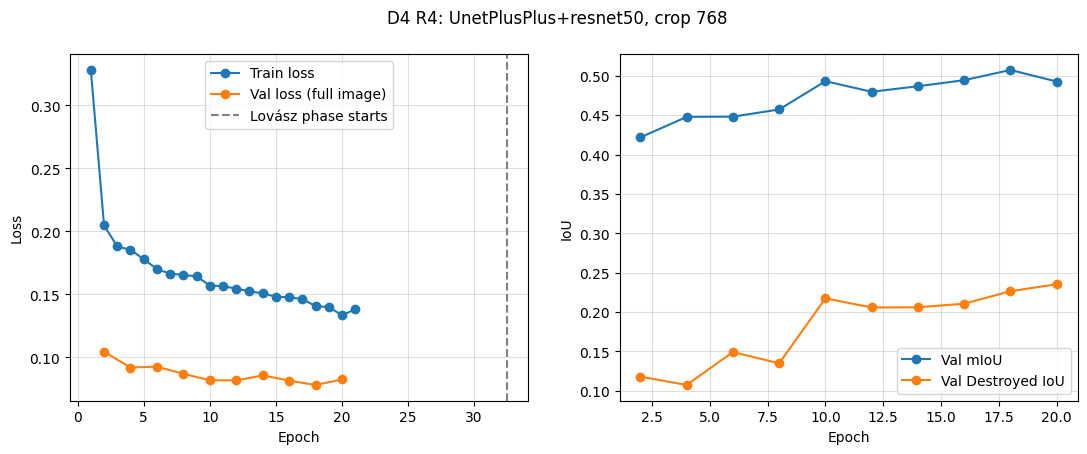

⚠ HF push failed: (Request ID: Root=1-6ac4595c-5550a27d5ecb67780364aa61;ca3389c8-f211-4bf7-8ef3-f21c89cb27d9)

403 Forbidden: You don't have the rights to create a model under the namespace "AbrarAlam".
Cannot access content at: https://huggingface.co/api/repos/create.
Make sure your token has the correct permissions.


In [12]:
# ── Cell 12: Training curves ───────────────────────────────────────────────
import matplotlib.pyplot as plt

if not CFG["eval_only"] and history["epoch"]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    ax1.plot(history["epoch"], history["train_loss"], marker="o", label="Train loss")
    val_pts = [(e, v) for e, v in zip(history["epoch"], history["val_loss"]) if v is not None]
    if val_pts:
        ax1.plot(*zip(*val_pts), marker="o", label="Val loss (full image)")
    ax1.axvline(criterion.lovasz_start_epoch + 0.5, color="grey", ls="--", label="Lovász phase starts")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.grid(alpha=0.4)

    miou_pts = [(e, v) for e, v in zip(history["epoch"], history["val_miou"]) if v is not None]
    dest_pts = [(e, v) for e, v in zip(history["epoch"], history["val_destroyed_iou"]) if v is not None]
    if miou_pts:
        ax2.plot(*zip(*miou_pts), marker="o", label="Val mIoU")
        ax2.plot(*zip(*dest_pts), marker="o", label="Val Destroyed IoU")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("IoU"); ax2.legend(); ax2.grid(alpha=0.4)
    fig.suptitle(f"D4 {EXPERIMENT}: {CFG['arch']}+{CFG['encoder']}, crop {CFG['crop']}")
    plot_path = RUN_DIR / "training_plot.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    push_to_hf([plot_path], f"{EXPERIMENT}: training plot")